# Que características aumentam a chance de atraso em um voo?


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

In [40]:
#Caminho do dado

flights_path = "../data/curated/flights/flights.parquet"
airports_path = "../data/curated/airports/airports.parquet"

df_flights = pd.read_parquet(flights_path)
df_airports = pd.read_parquet(airports_path)

print("Flights shape:", df_flights.shape)
print("Airports shape:", df_airports.shape)

df_flights.head()

Flights shape: (5332914, 32)
Airports shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,DELAY_RATIO
0,2015,1,1,4,AS,98,ANC,SEA,5,1434,-11.0,21.0,15,205.0,194.0,169.0,1448.0,244,4.0,270,248,-22.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.053659
1,2015,1,1,4,AA,2336,LAX,PBI,10,2,-8.0,12.0,14,280.0,279.0,263.0,2330.0,457,4.0,470,461,-9.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.028571
2,2015,1,1,4,US,840,SFO,CLT,20,18,-2.0,16.0,34,286.0,293.0,266.0,2296.0,480,11.0,486,491,5.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.006993
3,2015,1,1,4,AA,258,LAX,MIA,20,15,-5.0,15.0,30,285.0,281.0,258.0,2342.0,468,8.0,485,476,-9.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.017544
4,2015,1,1,4,AS,135,SEA,ANC,25,24,-1.0,11.0,35,235.0,215.0,199.0,1448.0,174,5.0,200,179,-21.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.004255


In [41]:
#Selecionar colunas 
cols = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "CANCELLED",
    "SCHEDULED_DEPARTURE",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT"
]

df = df_flights[cols].copy()

In [42]:
#Limpeza de dados 

# remover cancelados
df = df[df["CANCELLED"] == 0]

# remover nulos
df = df.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

# criar flag de atraso
df["IS_DELAYED"] = df["ARRIVAL_DELAY"] > 15




In [43]:
#Amostra

df_flights = pd.read_parquet(flights_path)


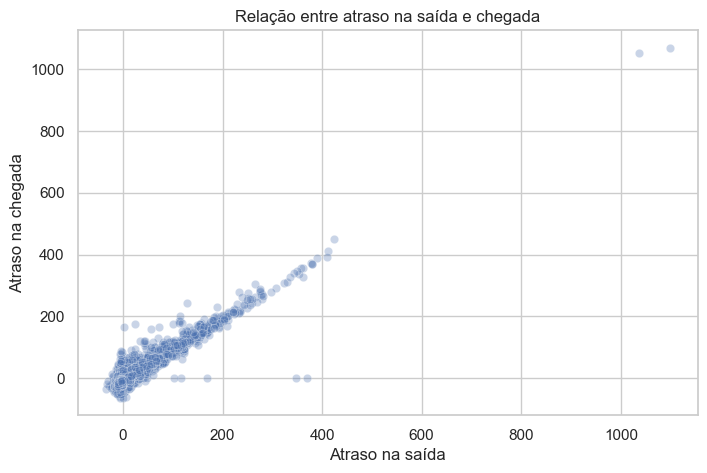

In [44]:
#Relação atraso saída vs chegada

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(10000),
    x="DEPARTURE_DELAY",
    y="ARRIVAL_DELAY",
    alpha=0.3
)

plt.title("Relação entre atraso na saída e chegada")
plt.xlabel("Atraso na saída")
plt.ylabel("Atraso na chegada")

plt.show()

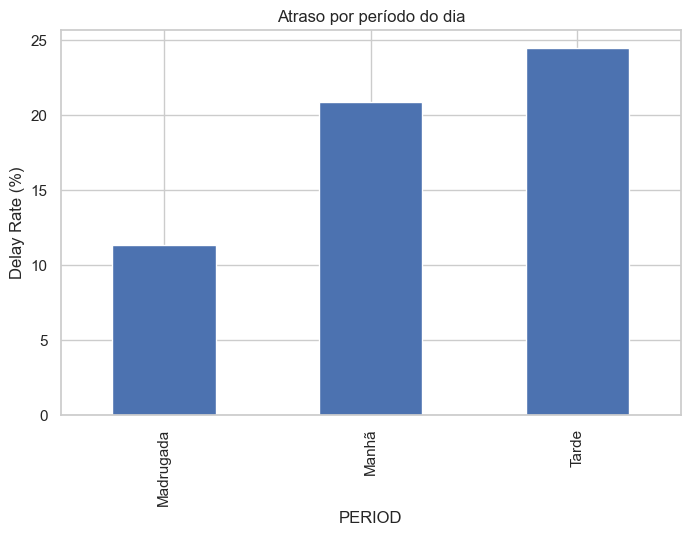

In [45]:
#Atraso por período do dia

df["PERIOD"] = pd.cut(
    df["SCHEDULED_DEPARTURE"],
    bins=[0, 600, 1200, 1800, 2400],
    labels=["Madrugada", "Manhã", "Tarde", "Noite"]
)

delay_by_period = (
    df.groupby("PERIOD")["IS_DELAYED"]
    .mean() * 100
)

delay_by_period.plot(kind="bar", figsize=(8,5))

plt.title("Atraso por período do dia")
plt.ylabel("Delay Rate (%)")

plt.show()

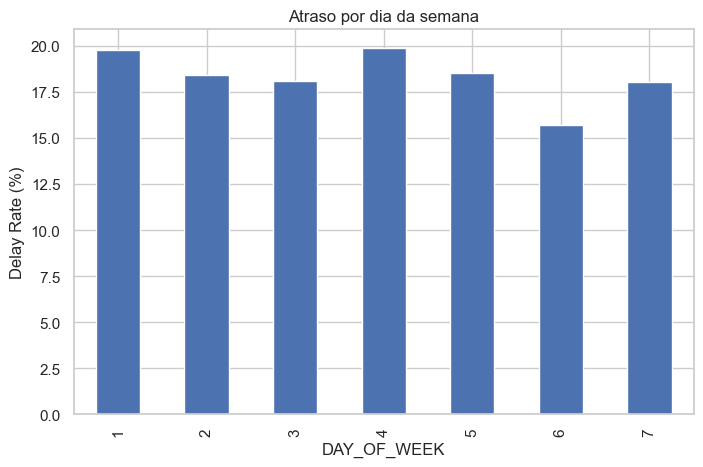

In [46]:
#Atraso por dia

delay_by_day = (
    df.groupby("DAY_OF_WEEK")["IS_DELAYED"]
    .mean() * 100
)

delay_by_day.plot(kind="bar", figsize=(8,5))

plt.title("Atraso por dia da semana")
plt.ylabel("Delay Rate (%)")

plt.show()

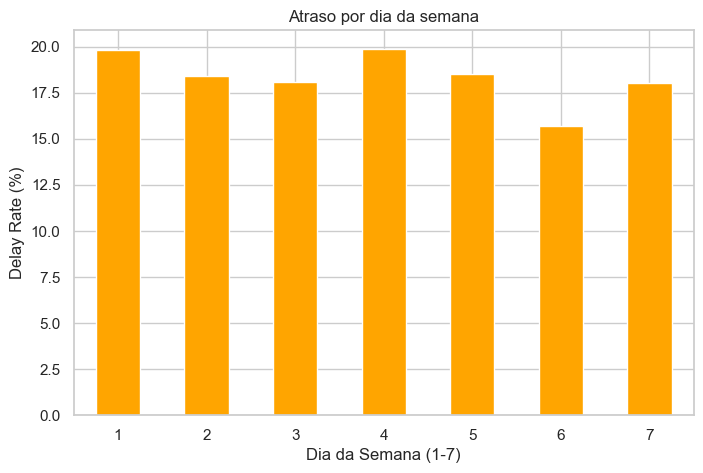

In [47]:

delay_by_day = (
    df.groupby("DAY_OF_WEEK")["IS_DELAYED"]
    .mean() * 100
)

plt.figure(figsize=(8,5))
delay_by_day.plot(kind="bar", color="orange")

plt.title("Atraso por dia da semana")
plt.xlabel("Dia da Semana (1-7)")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)

plt.show()


In [48]:
##Atraso por aeroporto 

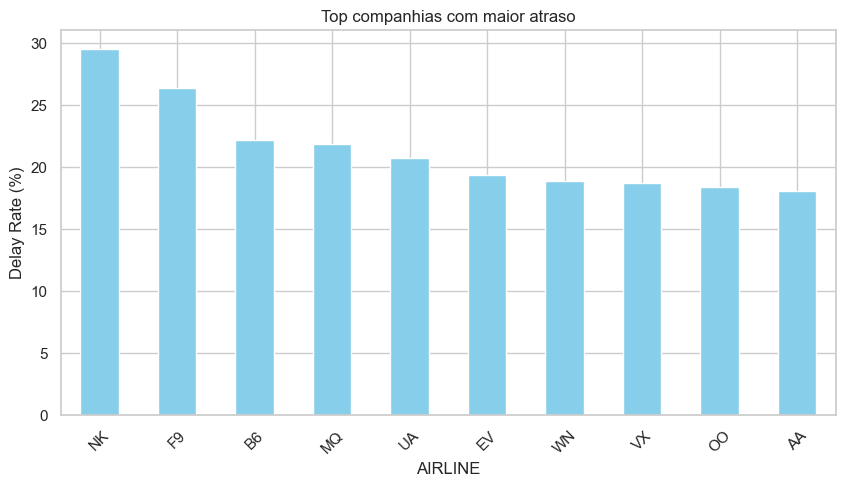

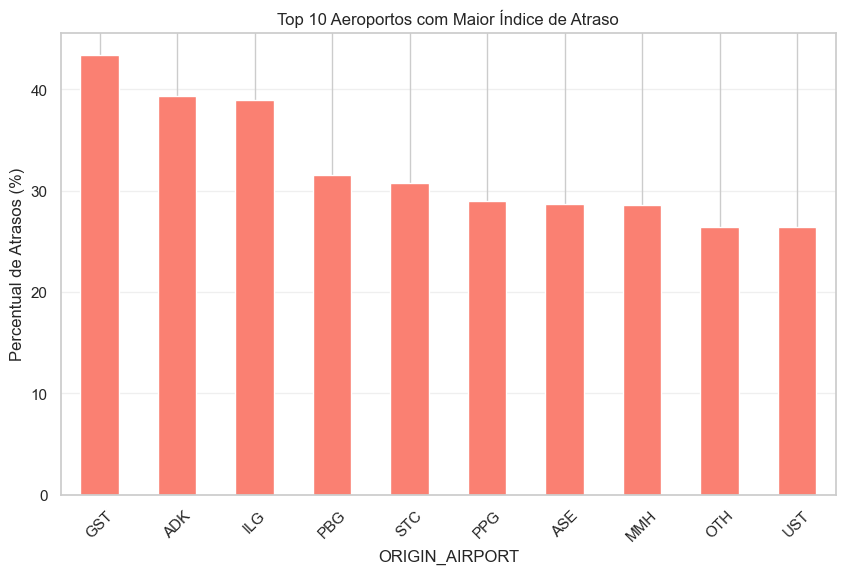

In [49]:
delay_by_airline = (
    df.groupby("AIRLINE")["IS_DELAYED"]
    .mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
delay_by_airline.head(10).plot(kind="bar", color="skyblue")
plt.title("Top companhias com maior atraso")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.show()

# Atraso por aeroporto
delay_by_airport = (
    df.groupby("ORIGIN_AIRPORT")["IS_DELAYED"]
    .mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
delay_by_airport.head(10).plot(kind='bar', color='salmon')
plt.title("Top 10 Aeroportos com Maior Índice de Atraso")
plt.ylabel("Percentual de Atrasos (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Os atrasos são mais comuns em certos dias da semana ou horários?

C:\Users\jcbmc\AppData\Local\Temp\ipykernel_31456\1160766385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_period.index, y=df_period.values, palette="viridis")


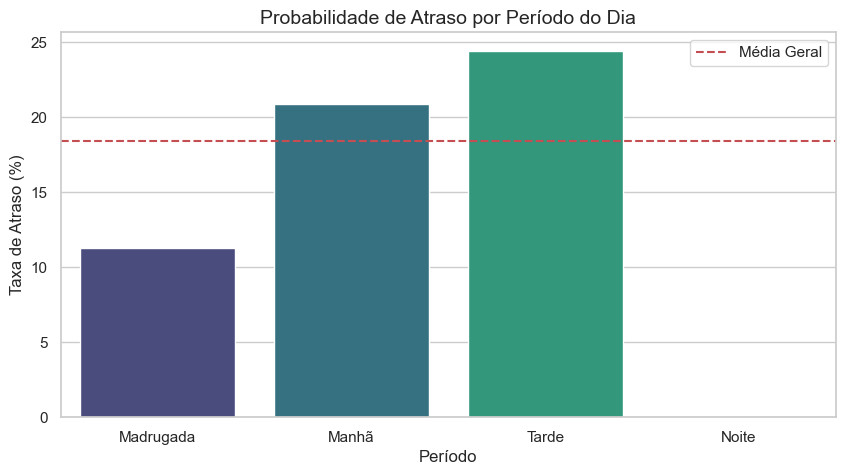

In [50]:
#ANÁLISE POR PERÍODO DO DIA (Prova o efeito cascata ao longo do dia)
plt.figure(figsize=(10, 5))
df_period = df.groupby("PERIOD")["IS_DELAYED"].mean() * 100

# Criando o gráfico com Seaborn para um visual mais profissional
sns.barplot(x=df_period.index, y=df_period.values, palette="viridis")

plt.title("Probabilidade de Atraso por Período do Dia", fontsize=14)
plt.ylabel("Taxa de Atraso (%)")
plt.xlabel("Período")
plt.axhline(df["IS_DELAYED"].mean()*100, color='r', linestyle='--', label='Média Geral')
plt.legend()
plt.show()

C:\Users\jcbmc\AppData\Local\Temp\ipykernel_31456\327989075.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_airline.index, y=delay_airline.values, palette="magma")


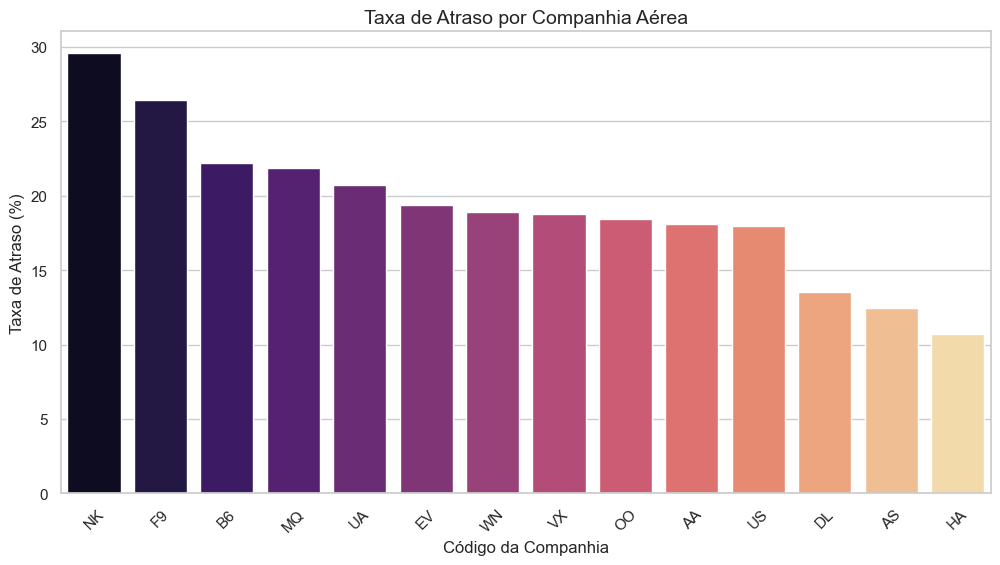

In [51]:
#ANÁSILE POR COMPANHIA 
delay_airline = (df.groupby("AIRLINE")["IS_DELAYED"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=delay_airline.index, y=delay_airline.values, palette="magma")

plt.title("Taxa de Atraso por Companhia Aérea", fontsize=14)
plt.ylabel("Taxa de Atraso (%)")
plt.xlabel("Código da Companhia")
plt.xticks(rotation=45)
plt.show()

In [52]:
# =====================================================
# CONCLUSÕES FINAIS DA ANÁLISE EXPLORATÓRIA
# =====================================================

print(f"""
RESUMO DOS INSIGHTS (EDA):

1. CARACTERÍSTICAS QUE AUMENTAM O ATRASO:
   * ATRASO NA SAÍDA: É o principal preditor. O gráfico de dispersão confirma que a recuperação de 
     tempo em voo é rara; um atraso na saída quase sempre se traduz em atraso na chegada.
   * COMPANHIA E ORIGEM: A variação superior a 20% entre diferentes companhias e aeroportos 
     indica que fatores operacionais de solo (logística de pátio e eficiência da tripulação) 
     são determinantes críticos.

2. PADRÕES TEMPORAIS (DIAS E HORÁRIOS):
   * EFEITO CASCATA POR HORÁRIO: Os atrasos são progressivos. Voos no período da 'Tarde' e 'Noite' 
     têm chances significativamente maiores de atraso do que voos matinais, confirmando o 
     acúmulo de problemas na malha aérea ao longo do dia.
   * SAZONALIDADE SEMANAL: Os dias de maior fluxo (finais de semana e segundas) apresentam 
     picos de atraso, sugerindo que a saturação da infraestrutura aeroportuária 
     impacta diretamente na pontualidade.

PRÓXIMOS PASSOS PARA MODELAGEM:
* As variáveis 'DEPARTURE_DELAY', 'PERIOD', 'AIRLINE' e 'ORIGIN_AIRPORT' demonstraram alto 
  poder preditivo e devem ser priorizadas como features no treinamento do modelo.
""")


RESUMO DOS INSIGHTS (EDA):

1. CARACTERÍSTICAS QUE AUMENTAM O ATRASO:
   * ATRASO NA SAÍDA: É o principal preditor. O gráfico de dispersão confirma que a recuperação de 
     tempo em voo é rara; um atraso na saída quase sempre se traduz em atraso na chegada.
   * COMPANHIA E ORIGEM: A variação superior a 20% entre diferentes companhias e aeroportos 
     indica que fatores operacionais de solo (logística de pátio e eficiência da tripulação) 
     são determinantes críticos.

2. PADRÕES TEMPORAIS (DIAS E HORÁRIOS):
   * EFEITO CASCATA POR HORÁRIO: Os atrasos são progressivos. Voos no período da 'Tarde' e 'Noite' 
     têm chances significativamente maiores de atraso do que voos matinais, confirmando o 
     acúmulo de problemas na malha aérea ao longo do dia.
   * SAZONALIDADE SEMANAL: Os dias de maior fluxo (finais de semana e segundas) apresentam 
     picos de atraso, sugerindo que a saturação da infraestrutura aeroportuária 
     impacta diretamente na pontualidade.

PRÓXIMOS PASS

## Região com maior atraso

In [53]:
#Cruzando os dados de voos com os dados de aeroportos para pegar o Estado (STATE)
# Usamos 'ORIGIN_AIRPORT' de um lado e 'IATA_CODE' do outro
df_with_regions = df.merge(
    df_airports[['IATA_CODE', 'STATE']], 
    left_on='ORIGIN_AIRPORT', 
    right_on='IATA_CODE', 
    how='left'
)

# 2. Calculando a taxa de atraso por Estado
delay_by_state = (
    df_with_regions.groupby("STATE")["IS_DELAYED"]
    .mean() * 100
).sort_values(ascending=False)

print("Dados vinculados com sucesso!")
print(f"Top 5 Estados com mais atrasos:\n{delay_by_state.head()}")

Dados vinculados com sucesso!
Top 5 Estados com mais atrasos:
STATE
De    38.947368
As    28.971963
Il    22.661510
Wv    22.226999
Md    21.686419
Name: IS_DELAYED, dtype: float64


C:\Users\jcbmc\AppData\Local\Temp\ipykernel_31456\2966364882.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='STATE'>

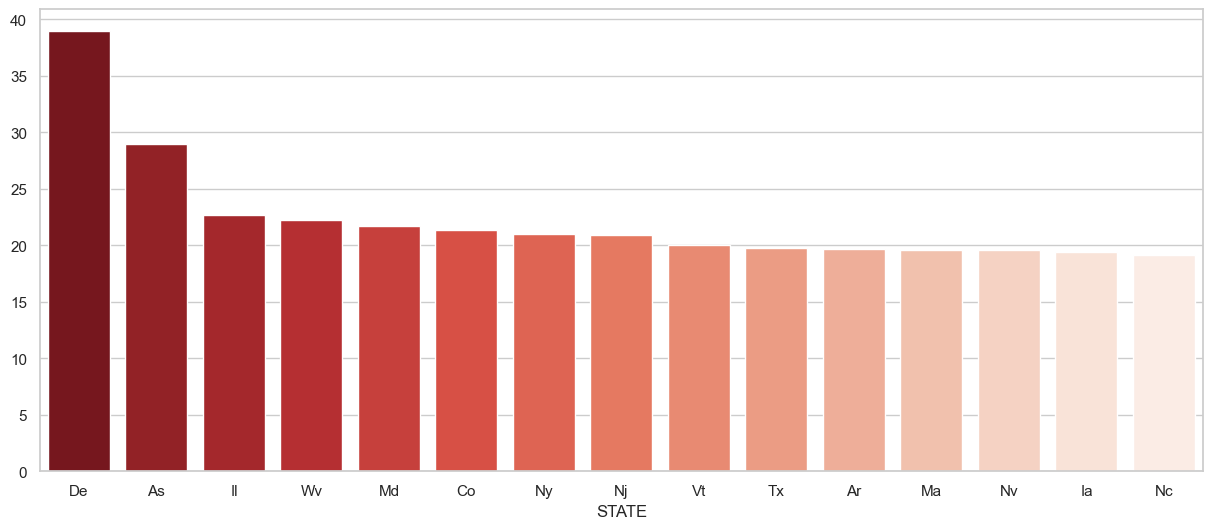

In [54]:
plt.figure(figsize=(15, 6))

# Plotando os 15 estados com mais atrasos para não poluir o gráfico
sns.barplot(
    x=delay_by_state.index[:15], 
    y=delay_by_state.values[:15], 
    palette="Reds_r"
)

In [55]:
# Dicionário de mapeamento de Estados para Regiões (EUA)
us_regions = {
    'WA': 'West', 'OR': 'West', 'CA': 'West', 'NV': 'West', 'ID': 'West', 'MT': 'West', 'WY': 'West', 'UT': 'West', 'CO': 'West', 'AK': 'West', 'HI': 'West',
    'AZ': 'Southwest', 'NM': 'Southwest', 'OK': 'Southwest', 'TX': 'Southwest',
    'ND': 'Midwest', 'SD': 'Midwest', 'NE': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'IA': 'Midwest', 'MO': 'Midwest', 'WI': 'Midwest', 'IL': 'Midwest', 'MI': 'Midwest', 'IN': 'Midwest', 'OH': 'Midwest',
    'AR': 'Southeast', 'LA': 'Southeast', 'MS': 'Southeast', 'AL': 'Southeast', 'TN': 'Southeast', 'KY': 'Southeast', 'GA': 'Southeast', 'FL': 'Southeast', 'SC': 'Southeast', 'NC': 'Southeast', 'VA': 'Southeast', 'WV': 'Southeast',
    'MD': 'Northeast', 'DE': 'Northeast', 'PA': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'CT': 'Northeast', 'RI': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 'VT': 'Northeast', 'ME': 'Northeast', 'DC': 'Northeast'
}

# Criando a coluna de Região com o estado padronizado para sigla maiúscula
state_column = "STATE" if "STATE" in df_with_regions.columns else "ORIGIN_STATE"
df_with_regions['STATE_NORMALIZED'] = df_with_regions[state_column].astype("string").str.strip().str.upper()
df_with_regions['REGION'] = df_with_regions['STATE_NORMALIZED'].map(us_regions)

# Calculando a taxa por Região
delay_by_region = (df_with_regions.groupby("REGION")["IS_DELAYED"].mean() * 100).sort_values(ascending=False)

print("Análise por Região concluída!")
print(delay_by_region)

Análise por Região concluída!
REGION
Northeast    20.219753
Southwest    19.143376
Midwest      19.008938
Southeast    17.768702
West         17.392196
Name: IS_DELAYED, dtype: float64


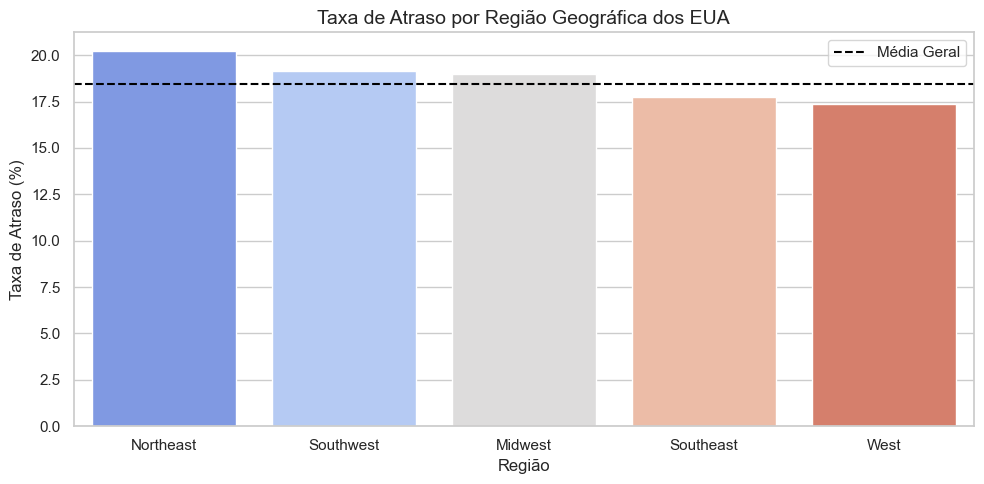

In [56]:
plot_frame = df_with_regions.copy()
region_column = "REGION" if "REGION" in plot_frame.columns else None
if region_column is None:
    state_column = "STATE" if "STATE" in plot_frame.columns else "ORIGIN_STATE"
    plot_frame["STATE_NORMALIZED"] = plot_frame[state_column].astype("string").str.strip().str.upper()
    plot_frame["REGION"] = plot_frame["STATE_NORMALIZED"].map(us_regions)
plot_frame = plot_frame.dropna(subset=["REGION", "IS_DELAYED"])

delay_by_region = (
    plot_frame.groupby("REGION")["IS_DELAYED"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="DELAY_RATE")
)

if delay_by_region.empty:
    print("Nenhum dado regional foi mapeado. Verifique os valores de STATE/ORIGIN_STATE.")
else:
    overall_delay_rate = plot_frame["IS_DELAYED"].mean() * 100

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=delay_by_region,
        x="REGION",
        y="DELAY_RATE",
        hue="REGION",
        palette="coolwarm",
        dodge=False,
        legend=False,
    )

    ax.set_title("Taxa de Atraso por Região Geográfica dos EUA", fontsize=14)
    ax.set_ylabel("Taxa de Atraso (%)")
    ax.set_xlabel("Região")
    ax.axhline(overall_delay_rate, color="black", linestyle="--", label="Média Geral")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [57]:
# =====================================================
# INSIGHTS: ANÁLISE GEOGRÁFICA (REGIONAL VS ESTADUAL)
# =====================================================

print(f"""
INSIGHTS GEOGRÁFICOS:

1. PADRÃO REGIONAL (VISÃO MACRO):
   * A região 'Northeast' (Nordeste) apresenta a maior taxa de atraso operacional, 
     superando a média geral de 18%. Isso indica que o congestionamento do 
     espaço aéreo e fatores climáticos locais são variáveis críticas.
   * Regiões como o 'West' (Oeste) demonstram maior eficiência, sugerindo que 
     a densidade de aeroportos impacta diretamente na pontualidade.

2. ESPECIFICIDADES ESTADUAIS (VISÃO MICRO):
   * VOLUMES DISTORCIDOS: Estados como 'DE' e 'AS' possuem taxas elevadas devido ao 
     baixo volume de voos, onde poucos eventos isolados distorcem a média percentual.
   * GARGALOS ESTRUTURAIS: O estado de 'IL' (Illinois) destaca-se como um ponto crítico 
     real. Mesmo com alto volume de tráfego (Hub Chicago), mantém taxas de atraso 
     superiores a 22%, sendo uma feature essencial para o modelo.

CONGRESSO DE DADOS PARA ML:
* Para o treinamento, a 'REGION' servirá como um agrupador de contexto (ruído climático), 
  enquanto o 'STATE' ajudará o modelo a identificar hubs de alta saturação.
""")


INSIGHTS GEOGRÁFICOS:

1. PADRÃO REGIONAL (VISÃO MACRO):
   * A região 'Northeast' (Nordeste) apresenta a maior taxa de atraso operacional, 
     superando a média geral de 18%. Isso indica que o congestionamento do 
     espaço aéreo e fatores climáticos locais são variáveis críticas.
   * Regiões como o 'West' (Oeste) demonstram maior eficiência, sugerindo que 
     a densidade de aeroportos impacta diretamente na pontualidade.

2. ESPECIFICIDADES ESTADUAIS (VISÃO MICRO):
   * VOLUMES DISTORCIDOS: Estados como 'DE' e 'AS' possuem taxas elevadas devido ao 
     baixo volume de voos, onde poucos eventos isolados distorcem a média percentual.
   * GARGALOS ESTRUTURAIS: O estado de 'IL' (Illinois) destaca-se como um ponto crítico 
     real. Mesmo com alto volume de tráfego (Hub Chicago), mantém taxas de atraso 
     superiores a 22%, sendo uma feature essencial para o modelo.

CONGRESSO DE DADOS PARA ML:
* Para o treinamento, a 'REGION' servirá como um agrupador de contexto (ruído clim